# Table of Contents

1. [Introduction](#Introduction)  
2. [Data](#Data)  
3. [Data Preparation](#Preprocessing-data)
4. [Exploratory Data Analysis](#Exploratory-Data-Analysis)  
5. [Feature Engineering (WOE & IV)](#Creating-weight-of-evidence-(WOE)-logsitic-regression)  
6. [Model Development](#Logistic-Regression-Model-Development)  
7. [Model Evaluation](#Model-Evaluation)  
8. [Stability Analysis (PSI)](#Stability-Analysis)  
9. [Calibration](#Calibration-Intercept-Adjustment)
10. [Decision Strategy](#Approval-vs-Risk-Trade-off)
11. [Conclusion](#Conclusion)    
12. [References](#References)

# Introduction
## Project overview

This project builds a Probability of Default (PD) model for mortgage loans in Wisconsin using traditional credit risk modeling methods. The analysis focuses on loans originated between 2020 and 2022. The goal is to predict whether a loan will default within 12 months of origination, to evaluate how well the model holds up over time, and demonstrate how the model can be used to support risk-based lending decisions. 

# Data

**Source:**
Freddie Mac Single-Family Loan-Level Dataset

**Scope:**
Geography: Wisconsin

**Time period:** 2020–2022 originations

**Data Components:**  
Origination data → borrower & loan characteristics  
Performance data → monthly loan outcomes  
Target Definition: Default within 12 months of origination
  

For detailed variable definitions and dataset structure, refer to the official Freddie Mac User Guide:  
https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset

In [2]:
import pandas as pd
import numpy as np
import glob
import os

# Assign column names (from User Guide)
acq_columns = ["credit_score",
    "first_payment_date",
    "first_time_homebuyer_flag",
    "maturity_date",
    "metropolitan_statistical_area",
    "mortgage_insurance_percentage",
    "number_of_units",
    "occupancy_status",
    "original_combined_loan_to_value",
    "original_debt_to_income_ratio",
    "original_upb",
    "original_loan_to_value",
    "original_interest_rate",
    "channel",
    "prepayment_penalty_mortgage_flag",
    "product_type",
    "property_state",
    "property_type",
    "postal_code",
    "loan_sequence_number",
    "loan_purpose",
    "original_loan_term",
    "number_of_borrowers",
    "seller_name",
    "servicer_name",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "program_indicator",
    "relocation_mortgage_indicator",
    "property_valuation_method",
    "interest_only_indicator",
    "mi_cancellation_indicator"]



# ---------- 1. Load Acquisition Files ----------
acq_files = glob.glob(r"local\mortage_pd_data\historical_data_*.txt")  # path to your acquisition txt files
acq_files = [f for f in acq_files if "time" not in f]  # ignore performance files

acq_list = []
for file in acq_files:
    df = pd.read_csv(file, sep="|", header=None, low_memory=False, names=acq_columns)
    acq_list.append(df)

df_acq = pd.concat(acq_list, ignore_index=True)
print("Acquisition data shape:", df_acq.shape)

Acquisition data shape: (9590864, 32)


In [4]:
df_acq.head()

,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,metropolitan_statistical_area,mortgage_insurance_percentage,number_of_units,occupancy_status,original_combined_loan_to_value,original_debt_to_income_ratio,...,number_of_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,relocation_mortgage_indicator,property_valuation_method,interest_only_indicator,mi_cancellation_indicator
0,661,202006,N,203505,41540.0,0,1,P,36,19,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,2,N,7
1,681,202003,N,205002,45820.0,30,1,P,95,13,...,1,Other sellers,"ROCKET MORTGAGE, LLC",NaN,NaN,9,NaN,2,N,N
2,775,202004,N,205003,NaN,25,1,P,87,29,...,2,Other sellers,PHH MORTGAGE CORPORATION,NaN,NaN,9,NaN,2,N,N
3,770,202003,N,203502,41180.0,0,2,I,65,14,...,1,Other sellers,Other servicers,NaN,NaN,9,NaN,2,N,7
4,791,202004,N,205003,10580.0,0,1,P,80,33,...,1,Other sellers,Other servicers,NaN,NaN,9,NaN,2,N,7


Due to the large size of the performance dataset, data was processed in chunks and restricted to the first 12 months after origination.  Loans were flagged as defaulted if any adverse event occurred during this period, and results were aggregated to create a single loan-level target variable.

In [ ]:
# Convert FIRST_PAYMENT_DATE (MM/YYYY) to datetime (monthly)
df_acq["orig_date"] = pd.to_datetime(df_acq["first_payment_date"], format="%Y%m")

# Create a fast lookup dictionary
orig_date_dict = dict(zip(df_acq["loan_sequence_number"], df_acq["orig_date"]))

In [ ]:
#  Define performance columns to keep
keep_cols = [
    "loan_sequence_number",
    "monthly_reporting_period",
    "current_loan_delinquency_status",
    "zero_balance_code"
]

perf_cols = [
    "loan_sequence_number",
    "monthly_reporting_period",
    "current_actual_upb",
    "current_loan_delinquency_status",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "repurchase_flag",
    "modification_flag",
    "zero_balance_code",
    "zero_balance_effective_date",
    "current_interest_rate",
    "current_deferred_upb",
    "due_date_of_last_paid_installment",
    "mi_recoveries",
    "net_sale_proceeds",
    "non_mi_recoveries",
    "expenses",
    "legal_costs",
    "maintenance_and_preservation_costs",
    "taxes_and_insurance",
    "miscellaneous_expenses",
    "actual_loss_calculation",
    "modification_cost",
    "step_modification_flag",
    "deferred_payment_plan",
    "estimated_loan_to_value",
    "zero_balance_removal_upb",
    "delinquent_accrued_interest",
    "delinquency_due_to_disaster",
    "borrower_assistance_status_code",
    "current_month_modification_cost",
    "interest_bearing_upb"
]

In [ ]:
# Prepare storage for final default flags
default_dict = {}

#  Loop through all performance files
perf_files = glob.glob(r"local\historical_data_time*.txt") # performance data

for file in perf_files:
    print(f"Processing {file}")
    
    # Read in chunks because data is too big
    chunks = pd.read_csv(file, sep="|", names=perf_cols, usecols=keep_cols, chunksize=1000000) # 1 million rows at a time
    
    for chunk in chunks:
        #  Convert monthly_reporting_period to datetime
        chunk["monthly_reporting_period"] = pd.to_datetime(chunk["monthly_reporting_period"], format="%Y%m", errors="coerce")
        
                #  Attach origination date
        chunk["orig_date"] = chunk["loan_sequence_number"].map(orig_date_dict) # orgination data from acquisition files
        
        #  Drop loans not in origination dataset in acquistions files
        chunk = chunk[chunk["orig_date"].notna()]
        
        #  Keep only first 12 months from first payment
        chunk = chunk[
            (chunk["monthly_reporting_period"] >= chunk["orig_date"]) &
            (chunk["monthly_reporting_period"] <= chunk["orig_date"] + pd.DateOffset(months=12))
        ]
        
        #  Define default flag
        chunk["default_flag"] = (
            (chunk["current_loan_delinquency_status"].astype(str) >= "3") |
            (chunk["zero_balance_code"].isin(["03", "06"]))  ## definition from User Guide
        ).astype(int)
        
        #  Aggregate per loan 1 defaulted else 0
        grouped = chunk.groupby("loan_sequence_number")["default_flag"].max()
        
        #  Update dictionary (loan_id, default flag)
        for loan, val in grouped.items():
            default_dict[loan] = max(default_dict.get(loan, 0), val)
        
        #  Convert dictionary to dataframe
pd_df = pd.DataFrame(
    list(default_dict.items()),
    columns=["loan_sequence_number", "default_12m"]
)

#  Merge with origination data
final_df = df_acq.merge(pd_df, on="loan_sequence_number", how="left")
final_df["default_12m"] = final_df["default_12m"].fillna(0) # assume 0 if no default was found

In [ ]:
# save dataframe to parquet 
final_df.to_parquet(r"local\mortage_default\pd_model_data.parquet")

In [5]:
# reading parquet data
final_df = pd.read_parquet(
    r"local\mortage_default\pd_model_data.parquet"
)

In [7]:
final_df.columns

Index(['credit_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date', 'metropolitan_statistical_area',
       'mortgage_insurance_percentage', 'number_of_units', 'occupancy_status',
       'original_combined_loan_to_value', 'original_debt_to_income_ratio',
       'original_upb', 'original_loan_to_value', 'original_interest_rate',
       'channel', 'prepayment_penalty_mortgage_flag', 'product_type',
       'property_state', 'property_type', 'postal_code',
       'loan_sequence_number', 'loan_purpose', 'original_loan_term',
       'number_of_borrowers', 'seller_name', 'servicer_name',
       'super_conforming_flag', 'pre_harp_loan_sequence_number',
       'program_indicator', 'relocation_mortgage_indicator',
       'property_valuation_method', 'interest_only_indicator',
       'mi_cancellation_indicator', 'orig_date', 'default_12m'],
      dtype='object')

In [6]:
final_df.describe()

,credit_score,first_payment_date,maturity_date,metropolitan_statistical_area,mortgage_insurance_percentage,number_of_units,original_combined_loan_to_value,original_debt_to_income_ratio,original_upb,original_loan_to_value,original_interest_rate,postal_code,original_loan_term,number_of_borrowers,pre_harp_loan_sequence_number,relocation_mortgage_indicator,property_valuation_method,orig_date,default_12m
count,9.590864e+06,9.590864e+06,9.590864e+06,8.762228e+06,9.590864e+06,9.590864e+06,9.590864e+06,9.590864e+06,9.590864e+06,9.590864e+06,9.590864e+06,9.590864e+06,9.590864e+06,9.590864e+06,0.0,0.0,9.590864e+06,9590864,9.590864e+06
mean,7.544968e+02,2.020983e+05,2.047669e+05,3.030013e+04,5.505089e+00,1.025640e+00,7.050918e+01,3.414919e+01,2.906773e+05,7.031400e+01,3.308066e+00,5.479478e+04,3.211737e+02,1.479694e+00,NaN,NaN,1.640603e+00,2021-05-22 19:59:40.238192,6.928677e-03
min,3.000000e+02,2.020020e+05,2.027040e+05,1.018000e+04,0.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,9.000000e+03,2.000000e+00,1.500000e+00,6.000000e+02,8.400000e+01,1.000000e+00,NaN,NaN,1.000000e+00,2020-02-01 00:00:00,0.000000e+00
25%,7.230000e+02,2.020110e+05,2.050020e+05,1.930000e+04,0.000000e+00,1.000000e+00,6.000000e+01,2.700000e+01,1.790000e+05,6.000000e+01,2.750000e+00,3.000000e+04,3.600000e+02,1.000000e+00,NaN,NaN,1.000000e+00,2020-11-01 00:00:00,0.000000e+00
50%,7.620000e+02,2.021050e+05,2.050120e+05,3.192400e+04,0.000000e+00,1.000000e+00,7.400000e+01,3.500000e+01,2.640000e+05,7.400000e+01,3.000000e+00,5.400000e+04,3.600000e+02,1.000000e+00,NaN,NaN,2.000000e+00,2021-05-01 00:00:00,0.000000e+00
75%,7.890000e+02,2.021120e+05,2.051090e+05,3.974000e+04,0.000000e+00,1.000000e+00,8.000000e+01,4.200000e+01,3.770000e+05,8.000000e+01,3.500000e+00,8.400000e+04,3.600000e+02,2.000000e+00,NaN,NaN,2.000000e+00,2021-12-01 00:00:00,0.000000e+00
max,9.999000e+03,2.025050e+05,2.063080e+05,4.974000e+04,9.990000e+02,4.000000e+00,9.990000e+02,9.990000e+02,1.867000e+06,1.580000e+02,9.500000e+00,9.990000e+04,5.100000e+02,6.000000e+00,NaN,NaN,7.000000e+00,2025-05-01 00:00:00,1.000000e+00
std,1.212431e+02,7.484972e+01,6.072144e+02,1.128169e+04,1.087504e+01,2.085898e-01,1.759306e+01,1.283740e+01,1.475283e+05,1.758007e+01,9.021923e-01,2.992583e+04,7.156423e+01,5.190495e-01,NaN,NaN,4.809221e-01,NaN,8.294981e-02


# Preprocessing data

## Wisconsin data

In [8]:
wi = final_df[final_df["property_state"]== "WI"]

In [9]:
wi.shape

(161052, 34)

In [11]:
wi.describe()

,credit_score,first_payment_date,maturity_date,metropolitan_statistical_area,mortgage_insurance_percentage,number_of_units,original_combined_loan_to_value,original_debt_to_income_ratio,original_upb,original_loan_to_value,original_interest_rate,postal_code,original_loan_term,number_of_borrowers,pre_harp_loan_sequence_number,relocation_mortgage_indicator,property_valuation_method,orig_date,default_12m
count,161052.000000,161052.000000,161052.000000,125183.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,0.0,0.0,161052.000000,161052,161052.000000
mean,758.296060,202093.576565,204663.643314,31065.151530,5.903671,1.038838,72.153944,32.493816,223390.718526,71.963838,3.264380,53720.781487,309.317798,1.574485,NaN,NaN,1.677415,2021-05-06 23:21:13.854407,0.004346
min,600.000000,202002.000000,202709.000000,11540.000000,0.000000,1.000000,4.000000,1.000000,13000.000000,4.000000,1.750000,53000.000000,85.000000,1.000000,NaN,NaN,1.000000,2020-02-01 00:00:00,0.000000
25%,728.000000,202010.000000,204010.000000,29404.000000,0.000000,1.000000,61.000000,25.000000,143000.000000,61.000000,2.750000,53100.000000,240.000000,1.000000,NaN,NaN,1.000000,2020-10-01 00:00:00,0.000000
50%,766.000000,202104.000000,205010.000000,33340.000000,0.000000,1.000000,75.000000,33.000000,202000.000000,75.000000,3.000000,53500.000000,360.000000,2.000000,NaN,NaN,2.000000,2021-04-01 00:00:00,0.000000
75%,791.000000,202111.000000,205108.000000,33340.000000,0.000000,1.000000,80.000000,41.000000,283000.000000,80.000000,3.375000,54300.000000,360.000000,2.000000,NaN,NaN,2.000000,2021-11-01 00:00:00,0.000000
max,9999.000000,202403.000000,205302.000000,48140.000000,35.000000,4.000000,105.000000,999.000000,768000.000000,97.000000,8.125000,54900.000000,360.000000,6.000000,NaN,NaN,4.000000,2024-03-01 00:00:00,1.000000
std,143.085882,73.896636,667.137223,6795.120019,10.999760,0.228897,16.574846,10.651207,108058.460583,16.632988,0.901959,649.242651,78.542949,0.509379,NaN,NaN,0.468343,NaN,0.065784


In [ ]:
cols = ["credit_score", "original_debt_to_income_ratio"]

wi.loc[:, cols] = wi[cols].apply(
    lambda col: col.replace([9999, 999],
        col[~col.isin([9999, 999])].median()  ## Impute data with median
    )
)

In [12]:
wi.groupby("default_12m", as_index=False).agg(count = ("default_12m","count"))

,default_12m,count
0,0.0,160352
1,1.0,700


In [46]:
# features to keep
features = [
    # Core
    "credit_score",
    "original_loan_to_value",
    "original_combined_loan_to_value",
    "original_debt_to_income_ratio",
    "original_upb",
    "original_interest_rate",

    # Loan characteristics
    "loan_purpose",
    "occupancy_status",
    "property_state",
    "property_type",

    # Additional
    "mortgage_insurance_percentage",
    "number_of_units",
    "number_of_borrowers",
    "original_loan_term",
    "first_time_homebuyer_flag"
]

# Target variable
target = "default_12m"

# Keep only relevant columns
df_model = wi[features + [target]]


In [14]:
df_model.columns

Index(['credit_score', 'original_loan_to_value',
       'original_combined_loan_to_value', 'original_debt_to_income_ratio',
       'original_upb', 'original_interest_rate', 'loan_purpose',
       'occupancy_status', 'property_state', 'property_type',
       'mortgage_insurance_percentage', 'number_of_units',
       'number_of_borrowers', 'original_loan_term',
       'first_time_homebuyer_flag', 'default_12m'],
      dtype='object')

In [16]:
df_model.isnull().sum() # no missing values

credit_score                       0
original_loan_to_value             0
original_combined_loan_to_value    0
original_debt_to_income_ratio      0
original_upb                       0
original_interest_rate             0
loan_purpose                       0
occupancy_status                   0
property_state                     0
property_type                      0
mortgage_insurance_percentage      0
number_of_units                    0
number_of_borrowers                0
original_loan_term                 0
first_time_homebuyer_flag          0
default_12m                        0
dtype: int64

In [18]:
df_model.describe()

,credit_score,original_loan_to_value,original_combined_loan_to_value,original_debt_to_income_ratio,original_upb,original_interest_rate,mortgage_insurance_percentage,number_of_units,number_of_borrowers,original_loan_term,default_12m
count,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000,161052.000000
mean,758.296060,71.963838,72.153944,32.493816,223390.718526,3.264380,5.903671,1.038838,1.574485,309.317798,0.004346
std,143.085882,16.632988,16.574846,10.651207,108058.460583,0.901959,10.999760,0.228897,0.509379,78.542949,0.065784
min,600.000000,4.000000,4.000000,1.000000,13000.000000,1.750000,0.000000,1.000000,1.000000,85.000000,0.000000
25%,728.000000,61.000000,61.000000,25.000000,143000.000000,2.750000,0.000000,1.000000,1.000000,240.000000,0.000000
50%,766.000000,75.000000,75.000000,33.000000,202000.000000,3.000000,0.000000,1.000000,2.000000,360.000000,0.000000
75%,791.000000,80.000000,80.000000,41.000000,283000.000000,3.375000,0.000000,1.000000,2.000000,360.000000,0.000000
max,9999.000000,97.000000,105.000000,999.000000,768000.000000,8.125000,35.000000,4.000000,6.000000,360.000000,1.000000


# Split dataset

In [19]:
# valid loans 
wi_df = wi[wi['orig_date'] <= '2022-12-31']

train = wi_df[wi_df['orig_date'] < '2021-01-01'] #2020

val   = wi_df[(wi_df['orig_date'] >= '2021-01-01') & 
           (wi_df['orig_date'] < '2022-01-01')]  #2021

oot   = wi_df[wi_df['orig_date'] >= '2022-01-01'] #2022

# Exploratory Data Analysis

In [20]:
train.describe()

,credit_score,first_payment_date,maturity_date,metropolitan_statistical_area,mortgage_insurance_percentage,number_of_units,original_combined_loan_to_value,original_debt_to_income_ratio,original_upb,original_loan_to_value,original_interest_rate,postal_code,original_loan_term,number_of_borrowers,pre_harp_loan_sequence_number,relocation_mortgage_indicator,property_valuation_method,orig_date,default_12m
count,55338.000000,55338.000000,55338.000000,42527.000000,55338.000000,55338.000000,55338.000000,55338.000000,55338.000000,55338.000000,55338.000000,55338.000000,55338.000000,55338.000000,0.0,0.0,55338.000000,55338,55338.000000
mean,762.437837,202008.310673,204517.575084,30981.498201,5.395732,1.030305,72.177365,31.484405,219276.103220,71.951462,3.107227,53730.928114,301.230330,1.610575,NaN,NaN,1.630941,2020-08-10 11:33:14.969098,0.005891
min,600.000000,202002.000000,202709.000000,11540.000000,0.000000,1.000000,6.000000,2.000000,19000.000000,6.000000,1.750000,53000.000000,86.000000,1.000000,NaN,NaN,1.000000,2020-02-01 00:00:00,0.000000
25%,736.000000,202006.000000,203511.000000,29404.000000,0.000000,1.000000,62.000000,24.000000,143000.000000,62.000000,2.750000,53100.000000,180.000000,1.000000,NaN,NaN,1.000000,2020-06-01 00:00:00,0.000000
50%,772.000000,202008.000000,205005.000000,33340.000000,0.000000,1.000000,75.000000,32.000000,200000.000000,75.000000,3.000000,53500.000000,360.000000,2.000000,NaN,NaN,2.000000,2020-08-01 00:00:00,0.000000
75%,794.000000,202011.000000,205008.000000,33340.000000,0.000000,1.000000,80.000000,39.000000,277000.000000,80.000000,3.375000,54300.000000,360.000000,2.000000,NaN,NaN,2.000000,2020-11-01 00:00:00,0.000000
max,9999.000000,202012.000000,205011.000000,48140.000000,35.000000,4.000000,104.000000,50.000000,518000.000000,97.000000,6.125000,54900.000000,360.000000,6.000000,NaN,NaN,2.000000,2020-12-01 00:00:00,1.000000
std,111.780766,2.589075,678.551198,6676.359987,10.527469,0.205469,15.804234,9.840946,101270.845768,15.859281,0.492837,645.191625,81.429949,0.500752,NaN,NaN,0.482554,NaN,0.076528


In [21]:
train['default_12m'].sum()

np.float64(326.0)

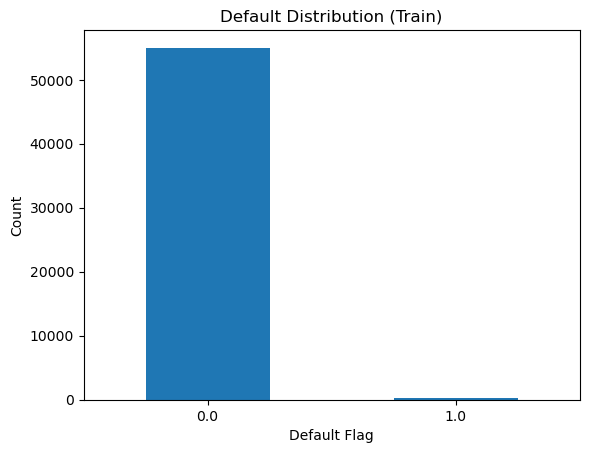

Default Rate: 0.005891069427879576


In [24]:
import matplotlib.pyplot as plt

train['default_12m'].value_counts().plot(kind="bar")
plt.title("Default Distribution (Train)")
plt.xlabel("Default Flag")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Default rate
print("Default Rate:", train['default_12m'].mean())

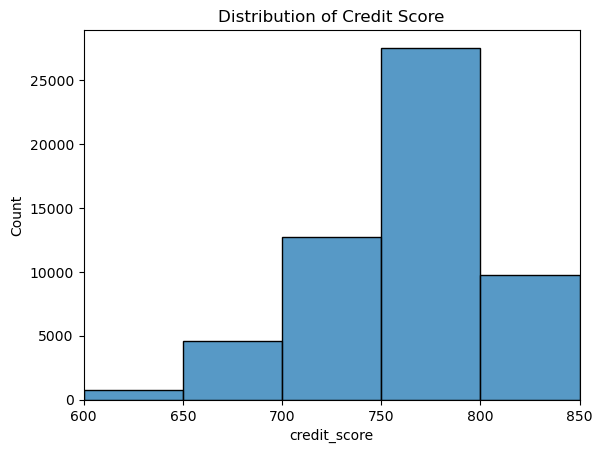

In [40]:
import seaborn as sns

sns.histplot(
    data=train,
    x="credit_score",
    bins=[600, 650, 700, 750, 800, 850]
)

plt.xlim(600, 850)
plt.title("Distribution of Credit Score")
plt.show()

In [43]:
num_cols = ["credit_score",
    "original_loan_to_value",
    "original_combined_loan_to_value",
    "original_debt_to_income_ratio",
    "original_upb",
    "original_interest_rate"]

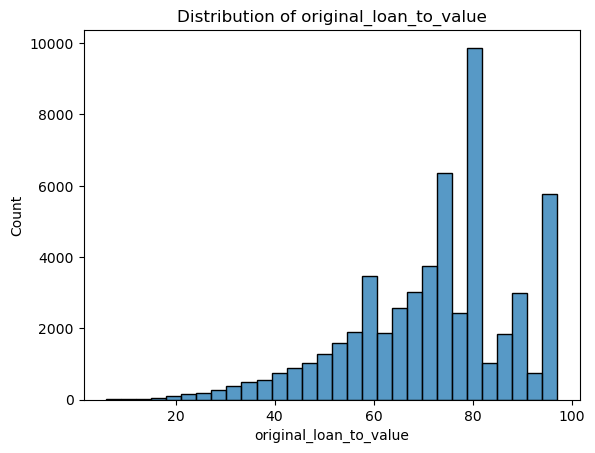

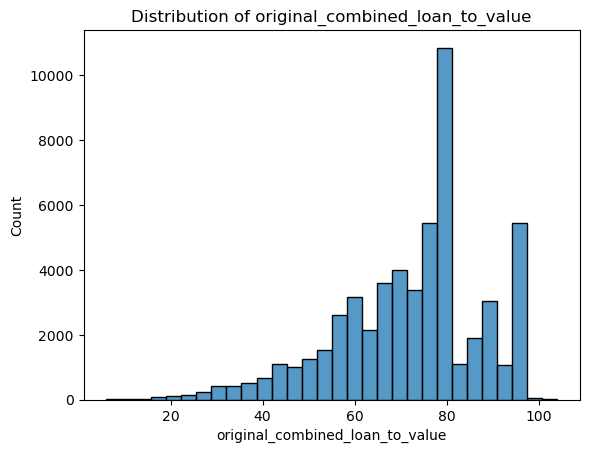

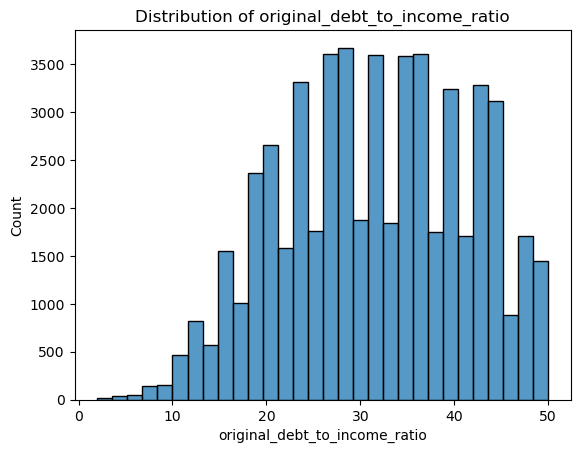

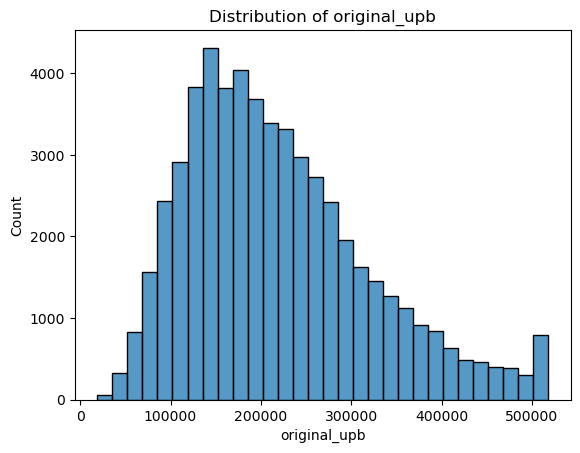

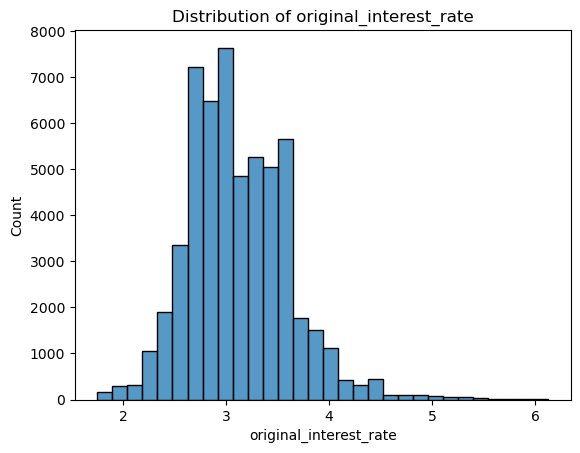

In [41]:

for col in num_cols:
    plt.figure()
    sns.histplot(train[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

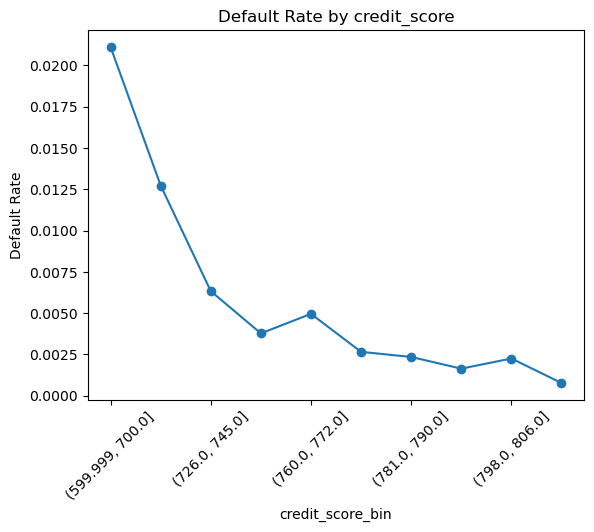

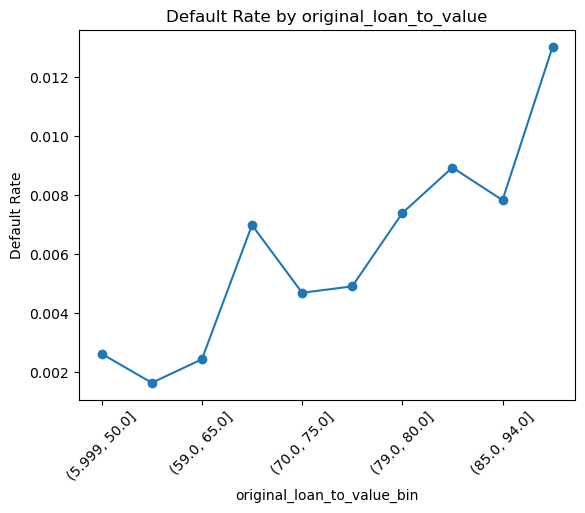

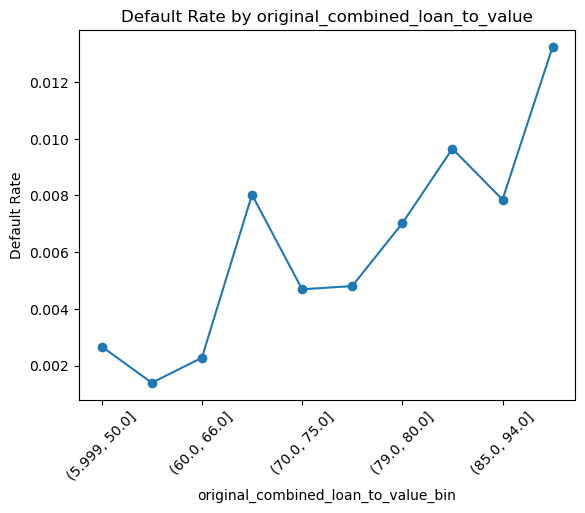

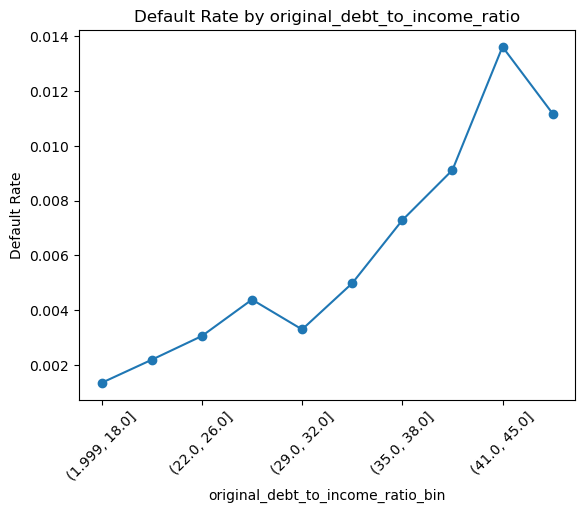

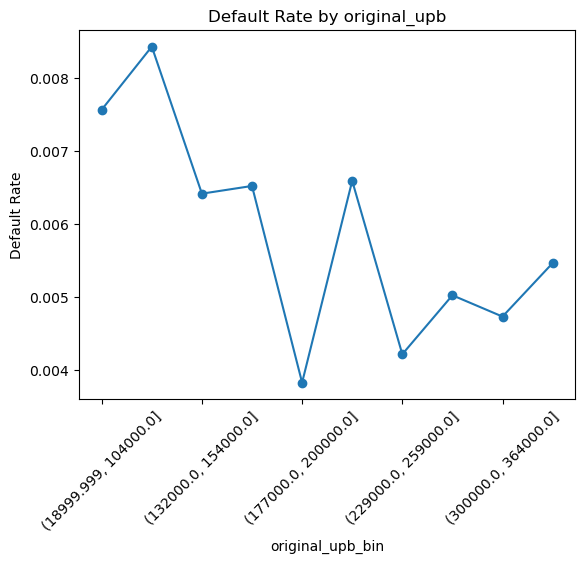

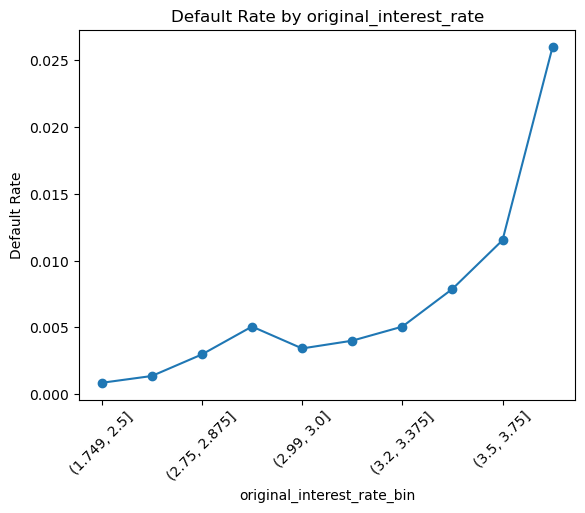

In [44]:
train = train.copy() 

for col in num_cols:
    bin_col = f"{col}_bin"
    
    train.loc[:, bin_col] = pd.qcut(train[col], q=10, duplicates="drop")
    
    temp = train.groupby(bin_col, observed=True)[target].mean()
    
    # plot
    temp.plot(kind="line", marker="o")
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Default Rate")
    plt.xticks(rotation=45)
    plt.show()

### Key take aways for EDA 
 -  Credit score, LTV/CLTV, DTI, and interest rate show strong and intuitive relationships with default risk, while loan size (UPB) exhibits weaker and less stable predictive behavior.


# Creating weight of evidence (WOE) logsitic regression

### WOE Transformation (R Implementation)

Weight of Evidence (WOE) binning was performed using the R **scorecard** package, which provides robust monotonic binning and Information Value (IV) calculations commonly used in credit risk modeling.

<details>
<summary>WOE Binning/ IV Code (R - scorecard package)</summary>

```r
library(tidyverse)
library(arrow)
library(scorecard)

train <- read_parquet("local\\mortage_default\\train.parquet")

train_df <- train %>% select(default_12m,  
                       credit_score,
                       original_loan_to_value,
                       original_combined_loan_to_value,
                       original_debt_to_income_ratio,
                       original_upb,
                       original_interest_rate,
                       loan_purpose,
                       occupancy_status,
                       property_state,
                       property_type,
                       number_of_borrowers,
                       mortgage_insurance_percentage,
                       original_loan_term,
                       first_time_homebuyer_flag,
                       orig_date) %>% 
  mutate(default_12m = as.integer(default_12m),
         number_of_borrowers = as.factor(number_of_borrowers),
         across(starts_with("original"), as.integer)) %>% 
  mutate_if(~ is.character(.), as.factor) 

#### for train ###
train_df_all <- woebin(train_df, y = "default_12m", positive = "bad|1")
training_woe <- woebin_ply(train_df, train_df_all)

iv_train <- iv(training_woe, y = "default_12m")

#### apply woe bins to val and oot sets ####
val <- read_parquet("local\\mortage_default\\val.parquet")
oot <- read_parquet("local\mortage_default\\oot.parquet")

val_df <- val %>% select(default_12m,  
                             credit_score,
                             original_loan_to_value,
                             original_combined_loan_to_value,
                             original_debt_to_income_ratio,
                             original_upb,
                             original_interest_rate,
                             loan_purpose,
                             occupancy_status,
                             property_state,
                             property_type,
                             number_of_borrowers,
                             mortgage_insurance_percentage,
                             original_loan_term,
                             first_time_homebuyer_flag,
                             orig_date) %>% 
  mutate(default_12m = as.integer(default_12m),
         number_of_borrowers = as.factor(number_of_borrowers),
         across(starts_with("original"), as.integer)) %>% 
  mutate_if(~ is.character(.), as.factor)


oot_df <- oot %>% select(default_12m,  
                             credit_score,
                             original_loan_to_value,
                             original_combined_loan_to_value,
                             original_debt_to_income_ratio,
                             original_upb,
                             original_interest_rate,
                             loan_purpose,
                             occupancy_status,
                             property_state,
                             property_type,
                             number_of_borrowers,
                             mortgage_insurance_percentage,
                             original_loan_term,
                             first_time_homebuyer_flag,
                             orig_date) %>% 
  mutate(default_12m = as.integer(default_12m),
         number_of_borrowers = as.factor(number_of_borrowers),
         across(starts_with("original"), as.integer)) %>% 
  mutate_if(~ is.character(.), as.factor)


#### val & oot ######
valid_woe <- woebin_ply(val_df, train_df_all) ## applying woe bins to validation set

oot_woe <- woebin_ply(oot_df, train_df_all) ## applying woe bins to oot set

write_parquet(training_woe, "local\\mortage_default\\training_woe.parquet")
write_parquet(training_woe, "local\\mortage_default\\iv_train.parquet")
write_parquet(valid_woe, "local\\valid_woe.parquet")
write_parquet(oot_woe, "local\\mortage_default\\oot_woe.parquet")
```
<details>

In [56]:
train_woe = pd.read_parquet(r"local\mortage_default\training_woe.parquet")
val_woe = pd.read_parquet(r"local\mortage_default\valid_woe.parquet")
oot_woe = pd.read_parquet(r"local\mortage_default\oot_woe.parquet")
iv = pd.read_parquet(r"local\mortage_default\iv_train.parquet")

### Weight of Evidence (WOE)

$$
\text{WOE}_i = \ln \left( \frac{\% \text{ Non-Defaults in Bin } i}{\% \text{ Defaults in Bin } i} \right)
$$

## Intrepretation
 - Positive WOE → more non-defaults → lower risk
 - Negative WOE → more defaults → higher risk

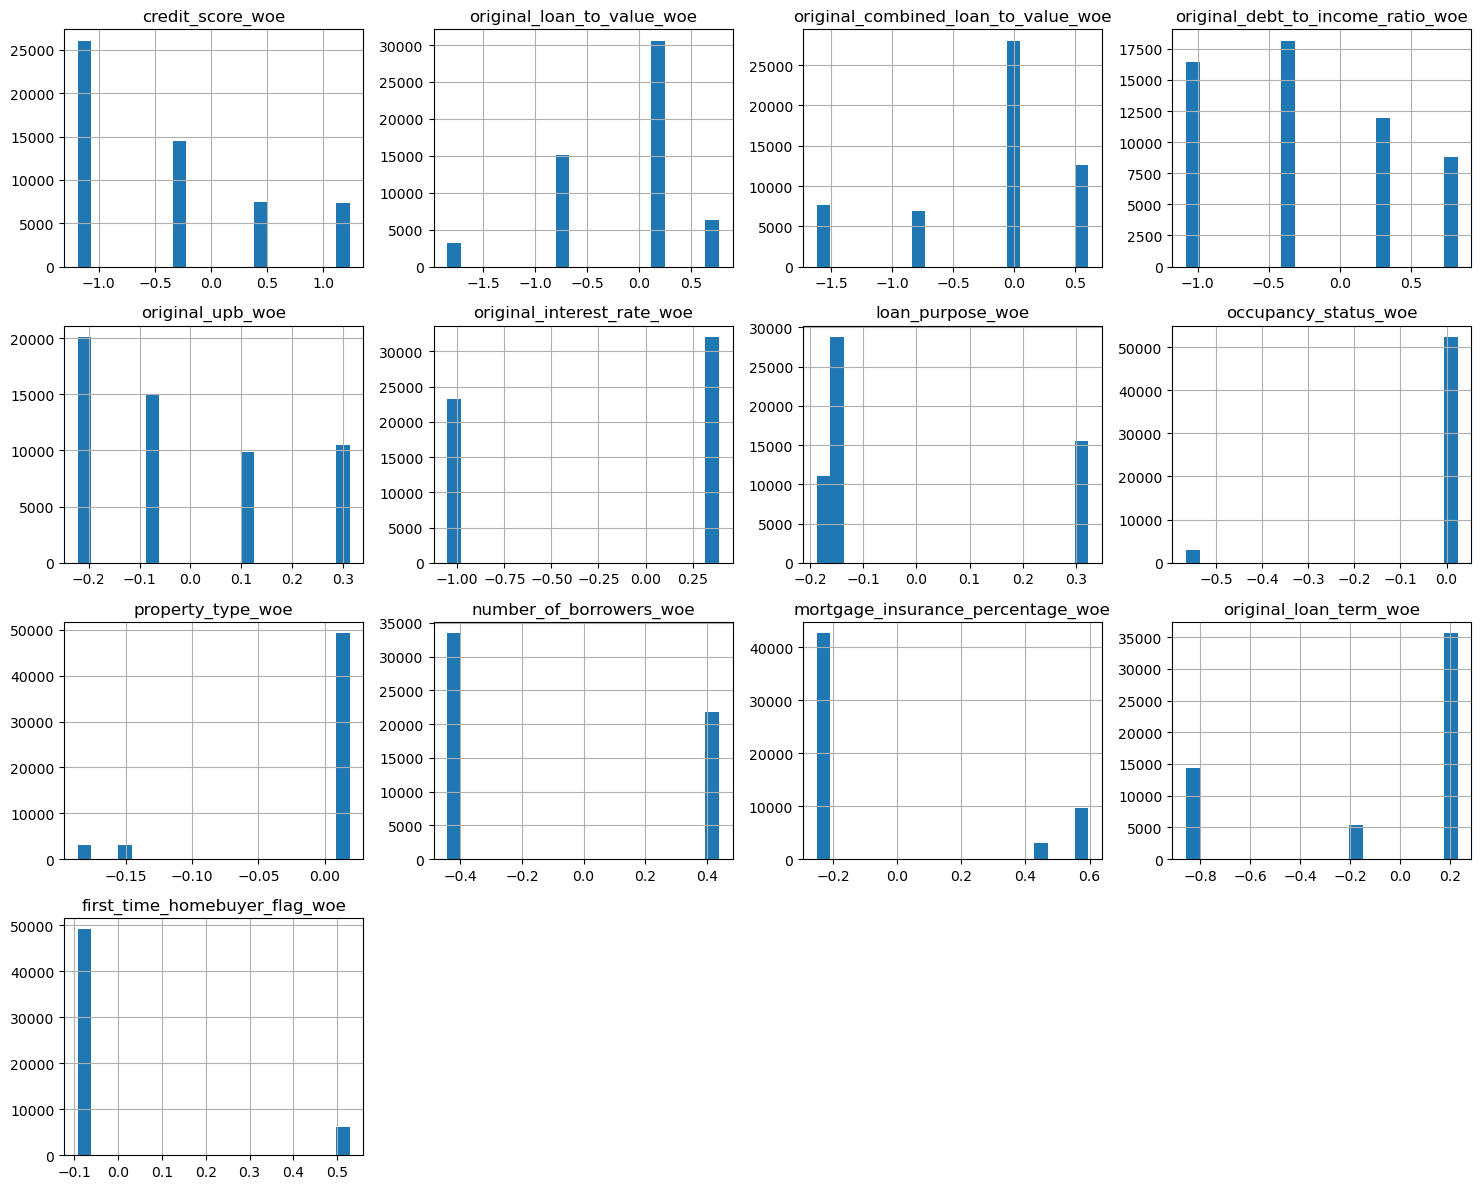

In [54]:
train_woe.drop(columns=['default_12m','orig_date']).hist(
    bins=20, figsize=(15, 12)
)
plt.tight_layout()
plt.show()

### Information Value (IV) using WOE

$$
IV = \sum_i \left( \% \text{non-default}_i - \% \text{default}_i \right)
\cdot \ln \left( \frac{\% \text{non-default}_i}{\% \text{default}_i} \right)
$$

Interpretation IV Range  
Weak < 0.10  
Moderate 0.10–0.40   
Strong 0.40   

Variables with low IV are weak predictors and were excluded from modeling.
 

In [57]:
iv

,variable,info_value
0,credit_score_woe,0.846579
1,original_debt_to_income_ratio_woe,0.442131
2,original_interest_rate_woe,0.397189
3,original_combined_loan_to_value_woe,0.354431
4,original_loan_to_value_woe,0.315359
5,number_of_borrowers_woe,0.191283
6,original_loan_term_woe,0.170095
7,mortgage_insurance_percentage_woe,0.140846
8,loan_purpose_woe,0.051795
9,first_time_homebuyer_flag_woe,0.048332


In [58]:
features_woe = [
    'credit_score_woe',
    'original_loan_to_value_woe',
    'original_combined_loan_to_value_woe',
    'original_debt_to_income_ratio_woe',
    'original_upb_woe',
    'original_interest_rate_woe',
    'number_of_borrowers_woe',
    'mortgage_insurance_percentage_woe',
    'original_loan_term_woe',
]

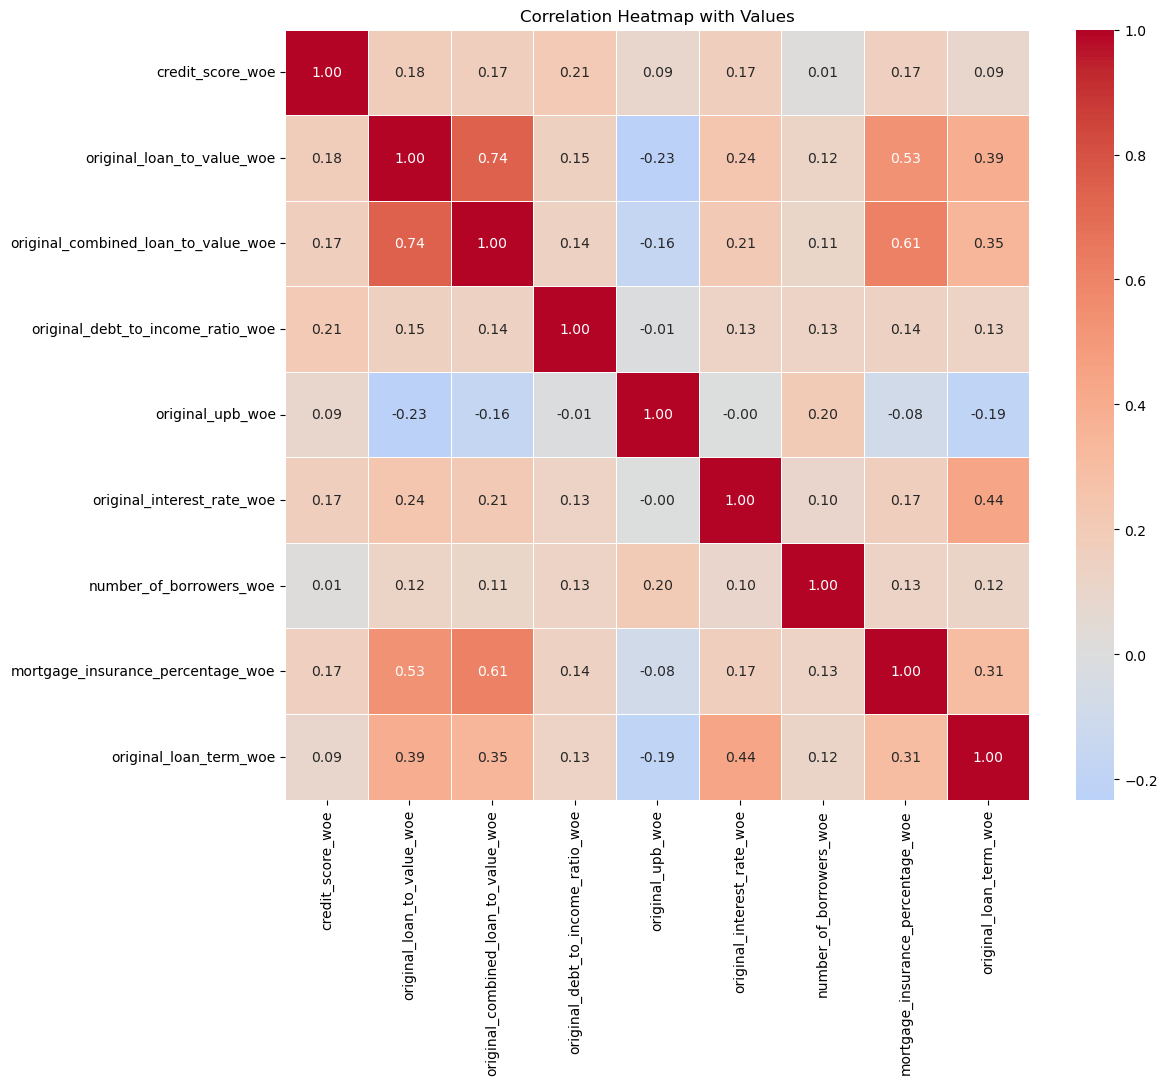

In [61]:
numeric_df = train_woe[features_woe].select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,        
    fmt=".2f",        
    linewidths=0.5
)

plt.title("Correlation Heatmap with Values")
plt.show()

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

features_woe = [
    'credit_score_woe',
    'original_loan_to_value_woe', # drop original ltv woe due redundant
    'original_combined_loan_to_value_woe',
    'original_debt_to_income_ratio_woe',
    'original_upb_woe',
    'original_interest_rate_woe',
    'loan_purpose_woe',
    'occupancy_status_woe',
    'property_type_woe',
    'number_of_borrowers_woe',
    'mortgage_insurance_percentage_woe',
    'original_loan_term_woe',
    'first_time_homebuyer_flag_woe'
]

X_woe = train_woe[features_woe]


vif_df = pd.DataFrame()
vif_df["feature"] = X_woe.columns
vif_df["VIF"] = [variance_inflation_factor(X_woe.values, i) for i in range(X_woe.shape[1])]

vif_df.sort_values(by="VIF", ascending=False)

,feature,VIF
2,original_combined_loan_to_value_woe,2.826241
1,original_loan_to_value_woe,2.711998
10,mortgage_insurance_percentage_woe,1.981896
6,loan_purpose_woe,1.822686
12,first_time_homebuyer_flag_woe,1.675576
11,original_loan_term_woe,1.571765
5,original_interest_rate_woe,1.397254
0,credit_score_woe,1.260864
4,original_upb_woe,1.204712
3,original_debt_to_income_ratio_woe,1.183553


In [64]:
features_eda = [
    'credit_score_woe',
    'original_combined_loan_to_value_woe',
    'original_debt_to_income_ratio_woe',
    'original_interest_rate_woe',
    'number_of_borrowers_woe',
    'mortgage_insurance_percentage_woe',
    'original_loan_term_woe',
]

# Logistic Regression Model Development

### Variable selection stepwise backward regression

In [65]:
import statsmodels.api as sm

X = train_woe[features_eda]   # WOE features
y = train_woe['default_12m']   # default 

X = sm.add_constant(X)

def backward_bic(X, y):
    variables = list(X.columns)
    best_bic = float('inf')
    
    while True:
        bic_list = []
        models = []
        var_combinations = []
        
        # try removing each variable
        for var in variables:
            if var == 'const':
                continue
                
            temp_vars = [v for v in variables if v != var]
            X_temp = X[temp_vars]
            
            model = sm.Logit(y, X_temp).fit(disp=0)
            
            bic_list.append(model.bic)
            models.append(model)
            var_combinations.append(temp_vars)
        
        # find best model this round
        min_bic = min(bic_list)
        min_index = bic_list.index(min_bic)
        
        # check if improvement
        if min_bic < best_bic:
            best_bic = min_bic
            variables = var_combinations[min_index]
            best_model = models[min_index]
            
            print(f"Dropped variable, new BIC: {best_bic:.2f}")
            print(f"Remaining vars: {variables}\n")
        else:
            break
    
    return best_model

In [66]:
final_model = backward_bic(X, y)

Dropped variable, new BIC: 3596.91
Remaining vars: ['const', 'credit_score_woe', 'original_combined_loan_to_value_woe', 'original_debt_to_income_ratio_woe', 'original_interest_rate_woe', 'number_of_borrowers_woe', 'mortgage_insurance_percentage_woe']

Dropped variable, new BIC: 3590.06
Remaining vars: ['const', 'credit_score_woe', 'original_combined_loan_to_value_woe', 'original_debt_to_income_ratio_woe', 'original_interest_rate_woe', 'number_of_borrowers_woe']



In [67]:
print(final_model.summary())

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:                55338
Model:                          Logit   Df Residuals:                    55332
Method:                           MLE   Df Model:                            5
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.1183
Time:                        17:44:29   Log-Likelihood:                -1762.3
converged:                       True   LL-Null:                       -1998.8
Covariance Type:            nonrobust   LLR p-value:                5.051e-100
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -5.1517      0.068    -76.046      0.000      -5.284      -5.019
credit_score_woe                        0.8241      0.06

Key Drivers of Default Risk
- **Credit Score** (WOE: 0.824)
→ Strongest predictor
→ Higher credit quality significantly reduces default risk
- **CLTV** (WOE: 0.528)
→ Higher leverage increases default risk
- **Debt-to-Income** (WOE: 0.661)
→ Higher DTI is associated with higher default risk
- **Interest Rate** (WOE: 0.601)
→ Higher rates reflect or contribute to higher risk
- **Number of Borrowers** (WOE: 0.786)
→ Loans with more borrowers tend to be less risky

In [68]:
dropped_vars = set(X.columns) - set(final_model.params.index)
print("Dropped variables:", dropped_vars)

Dropped variables: {'mortgage_insurance_percentage_woe', 'original_loan_term_woe'}


In [69]:
features_final = [
    'credit_score_woe',
    'original_combined_loan_to_value_woe',
    'original_debt_to_income_ratio_woe',
    'original_interest_rate_woe',
    'number_of_borrowers_woe',
]

# Model Evaluation

In [70]:
from sklearn.metrics import roc_auc_score

X_train_sm = sm.add_constant(train_woe[features_final])
y_train = train_woe['default_12m']
y_pred_train = final_model.predict(X_train_sm)

print("Train AUC:", roc_auc_score(y_train, y_pred_train))

Train AUC: 0.8174550817468047


In [71]:
# Val
X_val_sm = sm.add_constant(val_woe[features_final])
y_val = val_woe['default_12m']

# OOT
X_oot_sm = sm.add_constant(oot_woe[features_final])
y_oot = oot_woe['default_12m']

y_pred_val = final_model.predict(X_val_sm)
y_pred_oot = final_model.predict(X_oot_sm)

print("Val AUC:", roc_auc_score(y_val, y_pred_val))
print("OOT AUC:", roc_auc_score(y_oot, y_pred_oot))

Val AUC: 0.823908360510803
OOT AUC: 0.8082742451075394


In [74]:
from scipy.stats import ks_2samp

ks = ks_2samp(
    y_pred_oot[y_oot == 1],
    y_pred_oot[y_oot == 0]
).statistic

print("KS:", ks)

KS: 0.5142506766465065


In [73]:
df_d = pd.DataFrame({'y_true': y_oot, 'y_pred': y_pred_oot})

# Create deciles: 1 = highest PD, 10 = lowest
df_d['decile'] = pd.qcut(df_d['y_pred'], 10, labels=False)

# Reverse so 1 = highest PD
df_d['decile'] = 10 - df_d['decile']

# Create lift table
lift_table = df_d.groupby('decile', as_index=False).agg(
    avg_pred=('y_pred','mean'),
    actual_default=('y_true','mean'),
    count=('y_true','size')
)

overall_default_rate = df_d['y_true'].mean()

lift_table['lift'] = lift_table['actual_default'] / overall_default_rate

lift_table['defaults'] = lift_table['actual_default'] * lift_table['count']

lift_table['cum_defaults'] = lift_table['defaults'].cumsum()

total_defaults = lift_table['defaults'].sum()
lift_table['cum_default_rate'] = lift_table['cum_defaults'] / total_defaults

lift_table = lift_table.drop(columns='defaults')


print(lift_table)

   decile  avg_pred  actual_default  count      lift  cum_defaults  \
0       1  0.036924        0.022019   2952  4.415097          65.0   
1       2  0.020471        0.011403   2894  2.286434          98.0   
2       3  0.013900        0.005774   2944  1.157856         115.0   
3       4  0.009502        0.004341   3225  0.870445         129.0   
4       5  0.006747        0.001781   2808  0.357039         134.0   
5       6  0.004998        0.001406   2845  0.281917         138.0   
6       7  0.003493        0.001482   3373  0.297233         143.0   
7       8  0.002333        0.001361   2938  0.272993         147.0   
8       9  0.001480        0.000680   2940  0.136404         149.0   
9      10  0.000657        0.000317   3158  0.063494         150.0   

   cum_default_rate  
0          0.433333  
1          0.653333  
2          0.766667  
3          0.860000  
4          0.893333  
5          0.920000  
6          0.953333  
7          0.980000  
8          0.993333  
9        

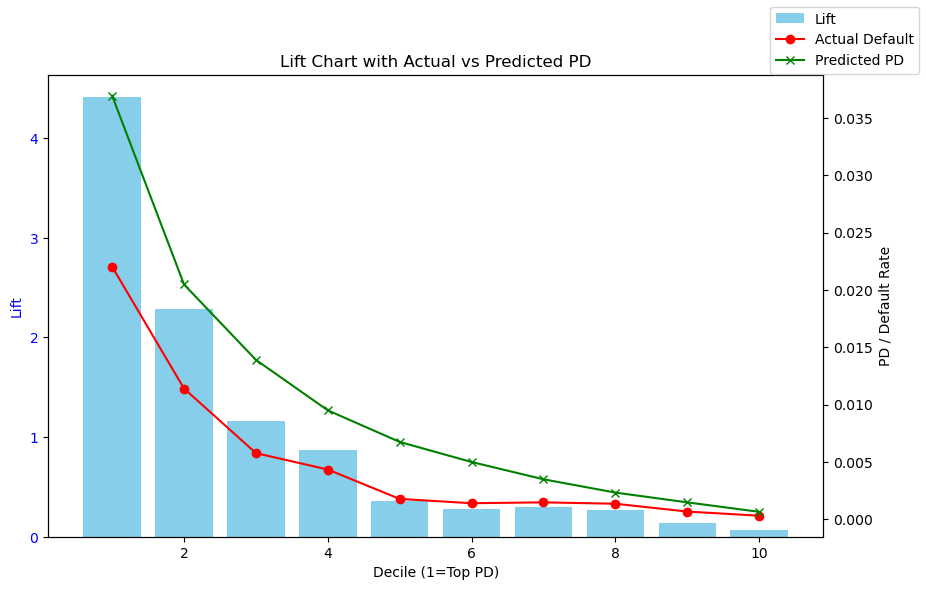

In [75]:
deciles = lift_table['decile']
pred_line = lift_table['avg_pred']
actual_line = lift_table['actual_default']
lift_bar = lift_table['lift']
counts = lift_table['count']

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar: Lift
ax1.bar(deciles, lift_bar, color='skyblue', label='Lift')
ax1.set_xlabel('Decile (1=Top PD)')
ax1.set_ylabel('Lift', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line: Actual vs Predicted
ax2 = ax1.twinx()
ax2.plot(deciles, actual_line, color='red', marker='o', label='Actual Default')
ax2.plot(deciles, pred_line, color='green', marker='x', label='Predicted PD')
ax2.set_ylabel('PD / Default Rate', color='black')
ax2.tick_params(axis='y', labelcolor='black')

fig.legend(loc='upper right')
plt.title('Lift Chart with Actual vs Predicted PD')
plt.show()

## Lift Chart Interpretation
- Top decile lift ≈ 4.4x
→ The highest-risk group has over 4x the average default rate
- Monotonic decline across deciles
→ Default rates consistently decrease from high-risk to low-risk groups
→ Confirms strong rank-ordering ability
- Predicted PD vs Actual Default
Predicted PD follows the same downward trend as actual defaults

Slight overestimation in higher-risk deciles, but overall alignment is strong

In [77]:
from sklearn.metrics import brier_score_loss

y_oot = y_oot.astype(int)

brier = brier_score_loss(y_oot, y_pred_oot)
print("Brier Score:", brier)

Brier Score: 0.00496672111025197


In [83]:
df_cali = pd.DataFrame({
    "y_true": y_val,
    "y_pred": y_pred_val
})

df_cali["bin"] = pd.qcut(df_cali["y_pred"], q=10, duplicates="drop")

calibration_table = df_cali.groupby("bin", observed=True).agg(
    avg_pred=("y_pred", "mean"),
    actual_rate=("y_true", "mean"),
    count=("y_true", "size")
).reset_index()

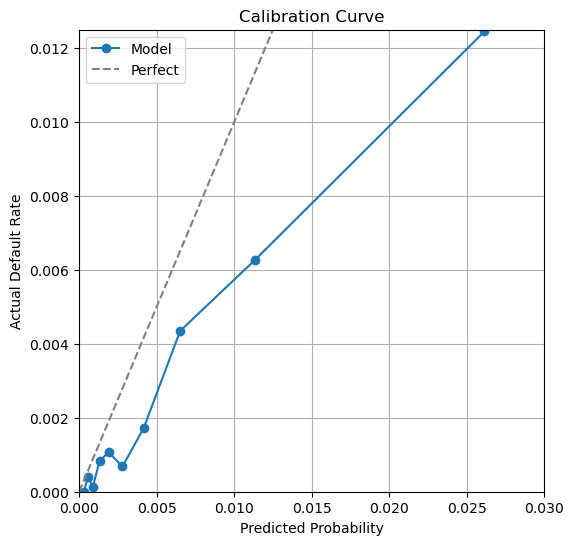

In [84]:

plt.figure(figsize=(6,6))

# model curve
plt.plot(calibration_table["avg_pred"],
         calibration_table["actual_rate"],
         marker="o",
         label="Model")

# perfect calibration line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect")

# 🔍 ZOOM HERE
plt.xlim(0, 0.03)
plt.ylim(0, 0.0125)

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid()

plt.show()

## Key Takeaways
- The model effectively ranks borrowers by risk, as shown by strong AUC and KS
- Performance is stable across train, validation, and OOT samples
- Lift chart confirms the model can identify high-risk segments effectively
- Predicted probabilities are directionally accurate, with minor calibration differences

# Stability Analysis

In [78]:
bins = 10

df_train_si = pd.DataFrame({'score': y_pred_train})
df_oot_si   = pd.DataFrame({'score': y_pred_oot})

# Create bins from TRAIN
df_train_si['bin'] = pd.qcut(df_train_si['score'], bins, duplicates='drop')

# Get bin edges
bin_edges = pd.qcut(df_train_si['score'], bins, duplicates='drop', retbins=True)[1]

# Apply to both
df_train_si['bin'] = pd.cut(df_train_si['score'], bins=bin_edges, include_lowest=True)
df_oot_si['bin']   = pd.cut(df_oot_si['score'], bins=bin_edges, include_lowest=True)

train_dist = df_train_si['bin'].value_counts(normalize=True).sort_index()
oot_dist   = df_oot_si['bin'].value_counts(normalize=True).sort_index()

psi_table = pd.DataFrame({
    'expected': train_dist,
    'actual': oot_dist
}).fillna(0.0001)

psi_table['psi'] = (psi_table['actual'] - psi_table['expected']) * \
                   np.log(psi_table['actual'] / psi_table['expected'])

psi_value = psi_table['psi'].sum()

print("PSI:", psi_value)

PSI: 0.33635431112297587


# Population Stability (PSI) 
- Score PSI = 0.33
- Indicates a significant shift between training and OOT populations
- Suggests that the distribution of predicted risk has changed
- Model still shows strong ranking performance (AUC / KS)
- However, population shift can lead to miscalibrated probabilities
- Predicted PDs may overestimate or underestimate actual default rates
- Recalibration needed to correct probability bias

## Investigating shift

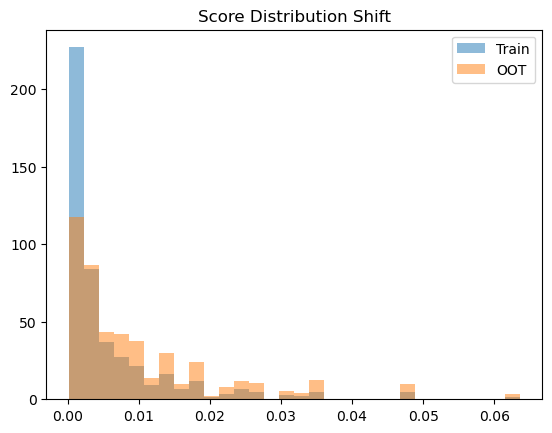

In [85]:
plt.hist(y_pred_train, bins=30, alpha=0.5, label='Train', density=True)
plt.hist(y_pred_oot, bins=30, alpha=0.5, label='OOT', density=True)

plt.legend()
plt.title('Score Distribution Shift')
plt.show()

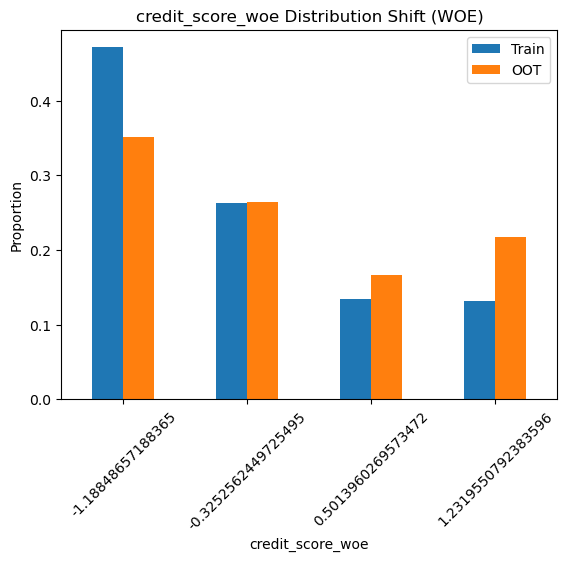

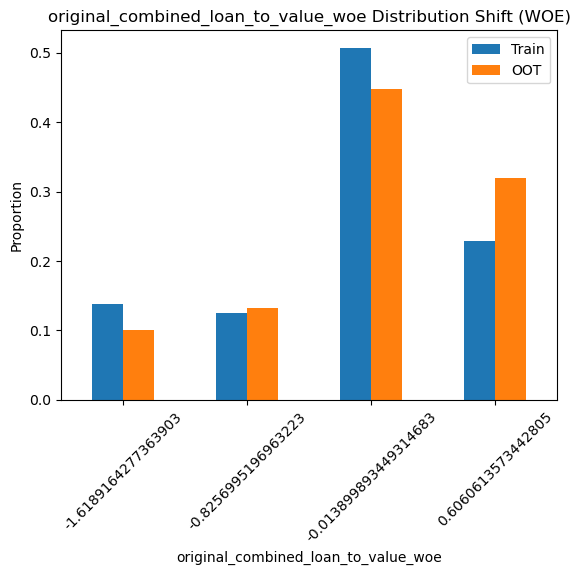

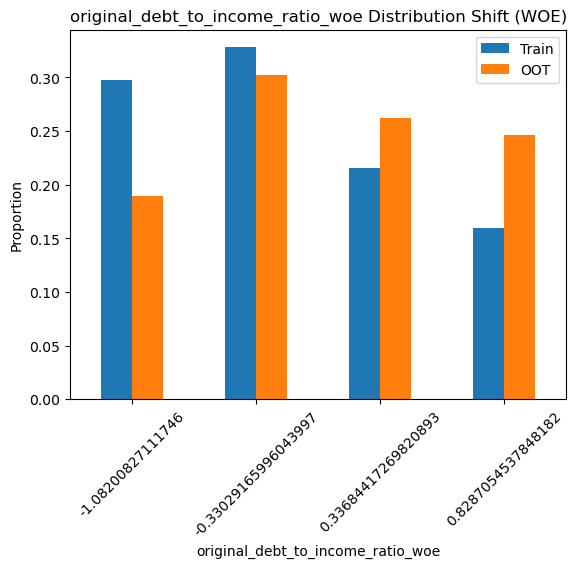

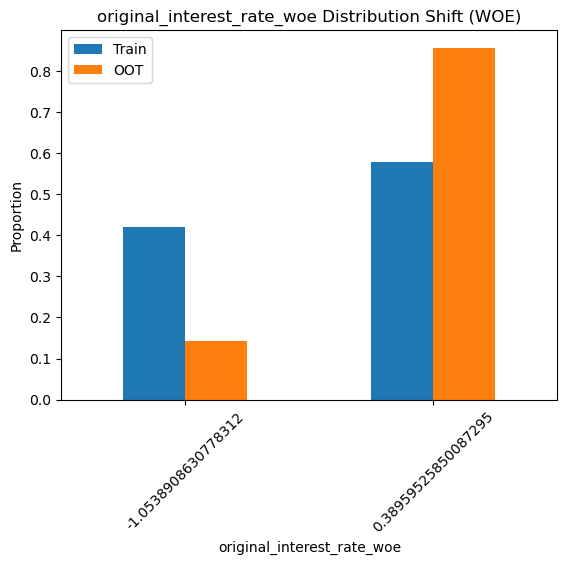

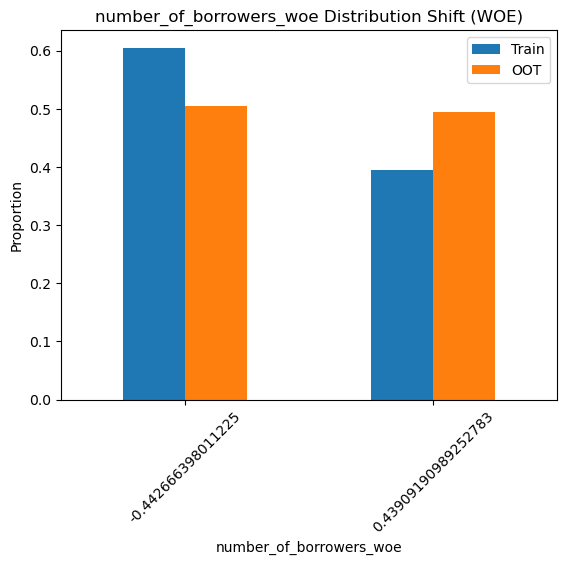

In [93]:
def plot_woe_bar(X_train_sm, X_oot_sm):

    woe_cols = [col for col in X_train_sm.columns if col.endswith('_woe')]
    
    for col in woe_cols:
        
        train_dist = X_train_sm[col].value_counts(normalize=True).sort_index()
        oot_dist   = X_oot_sm[col].value_counts(normalize=True).sort_index()
        
        df_plot = train_dist.to_frame('Train').join(oot_dist.to_frame('OOT')).fillna(0)
        
        df_plot.plot(kind='bar')
        plt.title(f'{col} Distribution Shift (WOE)')
        plt.ylabel('Proportion')
        plt.xticks(rotation=45)
        plt.show()

plot_woe_bar(X_train_sm, X_oot_sm)

Compared to training, the OOT population has higher interest rates, higher leverage (DTI/LTV), and lower credit quality, resulting in a shift toward higher-risk WOE bins and an elevated PSI.”

# Calibration Intercept Adjustment

A PSI of 0.33 indicates a significant population shift; however, since model discrimination remained strong (stable AUC and monotonic lift), I applied intercept-only recalibration to correct the predicted PD levels.

Using the validation set (2021), I compute a single adjustment to align predicted PDs with actual default rates, and apply it to recalibrate the model without changing its ranking.

Intercept shift delta: -0.7053994612521491

--- Mean PD vs Actual Default Rate ---
Validation actual default rate: 0.0027712119977178254
Validation mean PD before:      0.005560154637692661
Validation mean PD after:       0.0027712119977178233

OOT actual default rate:        0.004987199521228846
OOT mean PD before:             0.00990899846287258
OOT mean PD after:              0.004950893357449457

--- OOT Performance ---
OOT AUC before:    0.8082742451075394
OOT AUC after:     0.8082742451075394
Brier before:      0.00496672111025197
Brier after:       0.0049211645780162004


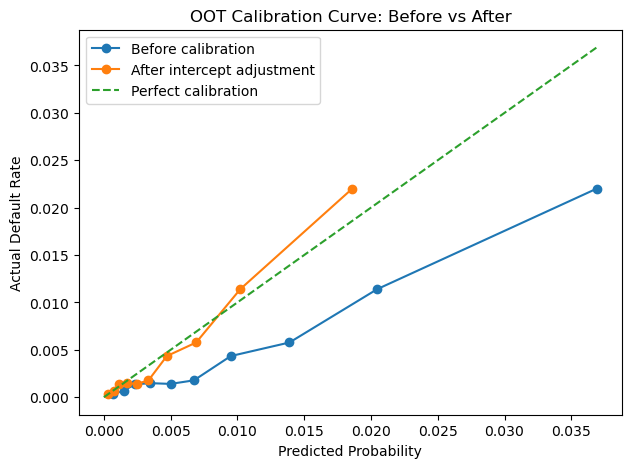

In [102]:
from scipy.special import expit, logit
from scipy.optimize import brentq
from sklearn.calibration import calibration_curve

# Fit intercept-only recalibration on VALIDATION
def fit_intercept_shift(y_true, p_pred, eps=1e-12):
    p_pred = np.clip(np.asarray(p_pred), eps, 1 - eps)
    y_true = np.asarray(y_true)

    logits = logit(p_pred)
    observed_rate = y_true.mean()

    def objective(delta):
        return expit(logits + delta).mean() - observed_rate

    delta = brentq(objective, -20, 20)
    return delta


# Apply that shift to any predicted probabilities
def apply_intercept_shift(p_pred, delta, eps=1e-12):
    p_pred = np.clip(np.asarray(p_pred), eps, 1 - eps)
    return expit(logit(p_pred) + delta)


# Fit delta on validation set
delta = fit_intercept_shift(y_val, y_pred_val)
print("Intercept shift delta:", delta)


# Apply to validation and OOT
y_pred_val_cal = apply_intercept_shift(y_pred_val, delta)
y_pred_oot_cal = apply_intercept_shift(y_pred_oot, delta)



# Compare average PD to actual default rate
print("\n--- Mean PD vs Actual Default Rate ---")
print("Validation actual default rate:", np.mean(y_val))
print("Validation mean PD before:     ", np.mean(y_pred_val))
print("Validation mean PD after:      ", np.mean(y_pred_val_cal))

print("\nOOT actual default rate:       ", np.mean(y_oot))
print("OOT mean PD before:            ", np.mean(y_pred_oot))
print("OOT mean PD after:             ", np.mean(y_pred_oot_cal))


#  Compare AUC and Brier on OOT
auc_before = roc_auc_score(y_oot, y_pred_oot)
auc_after  = roc_auc_score(y_oot, y_pred_oot_cal)

brier_before = brier_score_loss(y_oot, y_pred_oot)
brier_after  = brier_score_loss(y_oot, y_pred_oot_cal)

print("\n--- OOT Performance ---")
print("OOT AUC before:   ", auc_before)
print("OOT AUC after:    ", auc_after)
print("Brier before:     ", brier_before)
print("Brier after:      ", brier_after)


# Calibration curve on OOT: before vs after
prob_true_before, prob_pred_before = calibration_curve(
    y_oot, y_pred_oot, n_bins=10, strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_oot, y_pred_oot_cal, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_before, prob_true_before, marker='o', label='Before calibration')
plt.plot(prob_pred_after, prob_true_after, marker='o', label='After intercept adjustment')

max_x = max(prob_pred_before.max(), prob_pred_after.max())
plt.plot([0, max_x], [0, max_x], linestyle='--', label='Perfect calibration')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.title("OOT Calibration Curve: Before vs After")
plt.legend()
plt.show()

The model initially overestimated default probabilities due to a distribution shift (PSI = 0.33). Using the validation set, I estimated an intercept shift to align the average predicted PD with the observed default rate. Applying this adjustment to the OOT data improved calibration significantly while preserving model discrimination (AUC unchanged), resulting in well-calibrated PD estimates.

### Final Calibrated PD Model

Intercept shift (delta) = -0.7054
$$
\text{logit}(PD) =
-5.8571
+ 0.8241 \cdot \text{credit\_score\_woe}
+ 0.5275 \cdot \text{CLTV\_woe}
+ 0.6612 \cdot \text{DTI\_woe}
+ 0.6011 \cdot \text{rate\_woe}
+ 0.7860 \cdot \text{num\_borrowers\_woe}
$$

In [97]:
def plot_lift_before_after(y_true, p_before, p_after, n_bins=10):
    
    df = pd.DataFrame({
        'y': y_true,
        'p_before': p_before,
        'p_after': p_after
    })
    
    # Create deciles using BEFORE scores (important!)
    df['decile'] = pd.qcut(df['p_before'], n_bins, labels=False, duplicates='drop')
    df['decile'] = df['decile'] + 1  # make it 1–10
    
    # Sort so decile 1 = highest risk
    df['decile'] = n_bins - df['decile'] + 1
    
    # Aggregate
    lift_table = df.groupby('decile').agg({
        'y': ['mean', 'count'],
        'p_before': 'mean',
        'p_after': 'mean'
    }).reset_index()
    
    lift_table.columns = ['decile', 'actual_rate', 'count', 'pred_before', 'pred_after']
    
    # Compute lift
    overall_rate = df['y'].mean()
    lift_table['lift'] = lift_table['actual_rate'] / overall_rate
    
    # Plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Lift bars
    ax1.bar(lift_table['decile'], lift_table['lift'], alpha=0.6)
    ax1.set_xlabel('Decile (1 = highest risk)')
    ax1.set_ylabel('Lift')
    ax1.set_title('Lift Chart: Before vs After Calibration')
    
    # PD lines
    ax2 = ax1.twinx()
    ax2.plot(lift_table['decile'], lift_table['actual_rate'], marker='o', label='Actual', color='red')
    ax2.plot(lift_table['decile'], lift_table['pred_before'], marker='x', label='Predicted Before', color='blue')
    ax2.plot(lift_table['decile'], lift_table['pred_after'], marker='s', label='Predicted After', color='green')
    
    ax2.set_ylabel('Default Rate / PD')
    ax2.legend(loc='upper right')
    
    plt.show()
    
    return lift_table

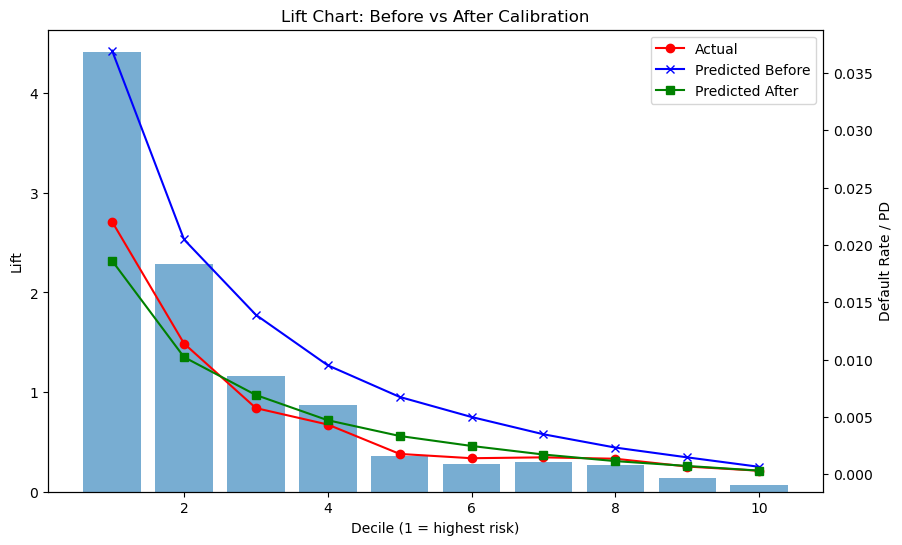

   decile  actual_rate  count  pred_before  pred_after      lift
0       1     0.022019   2952     0.036924    0.018613  4.415097
1       2     0.011403   2894     0.020471    0.010219  2.286434
2       3     0.005774   2944     0.013900    0.006914  1.157856
3       4     0.004341   3225     0.009502    0.004716  0.870445
4       5     0.001781   2808     0.006747    0.003344  0.357039
5       6     0.001406   2845     0.004998    0.002475  0.281917
6       7     0.001482   3373     0.003493    0.001728  0.297233
7       8     0.001361   2938     0.002333    0.001153  0.272993
8       9     0.000680   2940     0.001480    0.000732  0.136404
9      10     0.000317   3158     0.000657    0.000325  0.063494


In [98]:
lift_table_ba = plot_lift_before_after(
    y_oot,
    y_pred_oot,
    y_pred_oot_cal
)

print(lift_table_ba)

## Key Takeaways
- Model maintains strong ranking ability (lift and decile ordering unchanged)
- Calibration significantly improves probability accuracy
- Pre-calibration model overestimated default risk
- Intercept adjustment successfully realigns predictions with observed outcomes

# Approval vs Risk Trade-off

In [110]:
df_c = pd.DataFrame({
    "y": y_oot,
    "pd": y_pred_oot_cal
})


df_c["decile"] = pd.qcut(df_c["pd"], 10, labels=False, duplicates="drop") + 1
df_c["decile"] = 11 - df_c["decile"]

# Cutoffs based on deciles
cutoffs = df_c.groupby("decile")["pd"].max().sort_values().values

results = []

for c in cutoffs:
    approved = df_c[df_c["pd"] <= c]

    approval_rate = len(approved) / len(df_c)

    if len(approved) > 0:
        default_rate = approved["y"].mean()
        num_defaults = approved["y"].sum()
    else:
        default_rate = 0
        num_defaults = 0

    results.append([c, approval_rate, default_rate, num_defaults, len(approved)])

cutoff_df = pd.DataFrame(results, columns=[
    "cutoff", "approval_rate", "default_rate", "num_defaults", "num_loans"
])

portfolio_default_rate = df_c["y"].mean()

cutoff_df["relative_risk"] = cutoff_df["default_rate"] / portfolio_default_rate
cutoff_df["risk_multiple"] = portfolio_default_rate / cutoff_df["default_rate"]

print(cutoff_df)

     cutoff  approval_rate  default_rate  num_defaults  num_loans  \
0  0.000498       0.104997      0.000317             1       3158   
1  0.000929       0.202746      0.000492             3       6098   
2  0.001409       0.300429      0.000775             7       9036   
3  0.002116       0.412574      0.000967            12      12409   
4  0.003069       0.507165      0.001049            16      15254   
5  0.003996       0.600525      0.001163            21      18062   
6  0.005589       0.707750      0.001644            35      21287   
7  0.008465       0.805632      0.002146            52      24231   
8  0.011972       0.901852      0.003134            85      27125   
9  0.032457       1.000000      0.004987           150      30077   

   relative_risk  risk_multiple  
0       0.063494      15.749576  
1       0.098645      10.137314  
2       0.155333       6.437762  
3       0.193904       5.157180  
4       0.210319       4.754671  
5       0.233129       4.289467  
6 

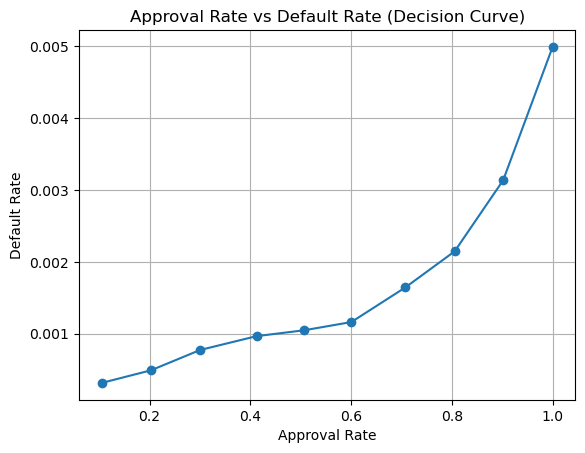

In [107]:
# Sort just in case
cutoff_df = cutoff_df.sort_values("approval_rate")

plt.figure()

plt.plot(cutoff_df["approval_rate"], cutoff_df["default_rate"], marker='o')

plt.xlabel("Approval Rate")
plt.ylabel("Default Rate")
plt.title("Approval Rate vs Default Rate (Decision Curve)")

plt.grid(True)

plt.show()

The chart shows how much risk is taken as more loans are approved. Lower cutoffs result in safer loans but fewer approvals, while higher cutoffs increase approvals but also increase default risk. The smooth and consistent trend demonstrates the model’s strong ability to effectively rank borrowers by risk.

# Conclusion

A Probability of Default (PD) model for Wisconsin mortgage loans (2020–2022) was developed using traditional credit risk techniques. The model demonstrates strong and stable performance, with consistent discriminatory power across training, validation, and out-of-time samples.

Population drift (PSI ≈ 0.33) led to systematic overestimation of default probabilities. An intercept-only recalibration successfully corrected this bias while preserving model ranking, resulting in a well-calibrated and interpretable model.

The model was further extended to a decision framework, demonstrating how PD-based cutoffs can be used to balance approval rates and default risk. This highlights the model’s practical application in supporting risk-based lending decisions.

## Next steps
- **Ongoing Model Monitoring**  
Continuously evaluate performance on new out-of-time (OOT) data  
Track key metrics: AUC, KS, Brier Score, and PSI   
- **Periodic Recalibration**  
Monitor calibration drift over time  
Apply calibration techniques as needed   
- **Stress Testing**  
Simulate adverse scenarios (e.g., higher DTI, lower credit scores, higher rates)  
Assess how predicted default rates change under stress conditions  
Evaluate model stability under shifting borrower characteristics  

- **Extend to Machine Learning Models**  
Develop alternative models such as:  
-- Random Forest  
--XGBoost   
Benchmark against logistic regression on:  
-- Predictive performance (AUC, KS)  
-- Calibration (Brier Score, calibration curves)  
-- Interpretability  
Compare how traditional vs machine learning models respond to drift 

# References

Freddie Mac. (2026). *Single-Family Loan-Level Dataset*. Retrieved from https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset

Bellini, T. (2019). *IFRS 9 and CECL Credit Risk Modelling and Validation: A Practical Guide with Examples Worked in R and SAS*. Academic Press.